In [1]:
# Cell 1 — Environment and GPU check

import importlib.util
import json
import random
import shutil
import subprocess
import sys
import tarfile
import time
import warnings
import zipfile
from collections import OrderedDict, defaultdict
from pathlib import Path

required_packages = {
    "nibabel": "nibabel",
    "scipy": "scipy",
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package_name]
        )

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import ndimage
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not enabled. In Kaggle, open Settings and set Accelerator to GPU."
    )

DEVICE = torch.device("cuda")
AMP_ENABLED = True

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
GPU: Tesla T4


In [2]:
# Cell 2 — Locate or extract the BraTS 2020 training dataset

INPUT_ROOT = Path("/kaggle/input")
EXTRACT_ROOT = Path("/kaggle/working/brats_flair_improved_extracted")
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

print("Attached inputs:")
for item in sorted(INPUT_ROOT.iterdir()):
    print("-", item.name)


def find_named_file(patient_dir: Path, suffix: str):
    for extension in (".nii.gz", ".nii"):
        candidate = patient_dir / f"{patient_dir.name}_{suffix}{extension}"
        if candidate.exists():
            return candidate
    return None


def patient_is_valid(patient_dir: Path):
    return (
        patient_dir.is_dir()
        and patient_dir.name.startswith("BraTS20_Training_")
        and find_named_file(patient_dir, "flair") is not None
        and find_named_file(patient_dir, "seg") is not None
    )


def locate_brats_root(search_root: Path):
    patient_dirs = [
        path
        for path in search_root.rglob("BraTS20_Training_*")
        if patient_is_valid(path)
    ]

    if not patient_dirs:
        return None

    parent_counts = defaultdict(int)

    for patient_dir in patient_dirs:
        parent_counts[patient_dir.parent] += 1

    return max(parent_counts, key=parent_counts.get)


def extract_archive(path: Path, destination: Path):
    destination.mkdir(parents=True, exist_ok=True)

    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path, "r") as archive:
            archive.extractall(destination)
        return

    if tarfile.is_tarfile(path):
        with tarfile.open(path, "r:*") as archive:
            archive.extractall(destination)
        return

    raise ValueError(f"Unsupported archive: {path}")


BRATS_ROOT = locate_brats_root(INPUT_ROOT)

if BRATS_ROOT is None:
    processed_archives = set()

    for round_number in range(3):
        archive_paths = []

        for root in (INPUT_ROOT, EXTRACT_ROOT):
            for pattern in ("*.zip", "*.tar", "*.tar.gz", "*.tgz"):
                archive_paths.extend(root.rglob(pattern))

        new_archives = [
            path
            for path in archive_paths
            if str(path.resolve()) not in processed_archives
        ]

        if not new_archives:
            break

        new_archives.sort(
            key=lambda path: (
                "train" not in path.name.lower(),
                "brats" not in path.name.lower(),
                str(path),
            )
        )

        for archive_path in new_archives:
            processed_archives.add(str(archive_path.resolve()))

            destination = (
                EXTRACT_ROOT
                / f"round_{round_number}_{archive_path.stem}"
            )

            try:
                print("Extracting:", archive_path)
                extract_archive(archive_path, destination)
            except Exception as error:
                print("Skipped:", archive_path.name, "-", error)
                continue

            BRATS_ROOT = locate_brats_root(EXTRACT_ROOT)

            if BRATS_ROOT is not None:
                break

        if BRATS_ROOT is not None:
            break

if BRATS_ROOT is None:
    raise FileNotFoundError(
        "BraTS20_Training_* patient folders were not found. "
        "Attach the same BraTS 2020 training dataset used previously."
    )

valid_patient_count = sum(
    patient_is_valid(path)
    for path in BRATS_ROOT.glob("BraTS20_Training_*")
)

print("BraTS root:", BRATS_ROOT)
print("Valid patients:", valid_patient_count)

Attached inputs:
- datasets
BraTS root: /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Valid patients: 368


In [3]:
# Cell 3 — Same-model improved configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Same model architecture:
INPUT_CHANNELS = 1
BASE_FILTERS = 16

# Improved training/preprocessing:
IMAGE_SIZE = 192
BATCH_SIZE = 8
NUM_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-5
NUM_WORKERS = 2

NEGATIVE_TO_POSITIVE_RATIO = 1.0
MIN_BRAIN_PIXELS = 200
MAX_PATIENTS = None

WORK_ROOT = Path("/kaggle/working")
PROCESSED_ROOT = WORK_ROOT / f"brats_flair_same_model_{IMAGE_SIZE}"
OUTPUT_ROOT = WORK_ROOT / "brats_flair_same_model_improved_outputs"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
RESULTS_DIR = OUTPUT_ROOT / "results"
FIGURE_DIR = OUTPUT_ROOT / "figures"

for directory in (
    PROCESSED_ROOT,
    OUTPUT_ROOT,
    CHECKPOINT_DIR,
    RESULTS_DIR,
    FIGURE_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "input_channels": INPUT_CHANNELS,
    "base_filters": BASE_FILTERS,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "negative_to_positive_ratio": NEGATIVE_TO_POSITIVE_RATIO,
    "seed": SEED,
    "brats_root": str(BRATS_ROOT),
}

with (OUTPUT_ROOT / "configuration.json").open("w") as file:
    json.dump(CONFIG, file, indent=2)

print(json.dumps(CONFIG, indent=2))
print("Output folder:", OUTPUT_ROOT)

{
  "input_channels": 1,
  "base_filters": 16,
  "image_size": 192,
  "batch_size": 8,
  "num_epochs": 25,
  "early_stopping_patience": 6,
  "learning_rate": 0.0002,
  "weight_decay": 1e-05,
  "negative_to_positive_ratio": 1.0,
  "seed": 42,
  "brats_root": "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
}
Output folder: /kaggle/working/brats_flair_same_model_improved_outputs


In [4]:
# Cell 4 — Reproduce the patient-level 70/15/15 split

cases = []

for patient_dir in sorted(BRATS_ROOT.glob("BraTS20_Training_*")):
    if not patient_is_valid(patient_dir):
        continue

    cases.append(
        {
            "case_id": patient_dir.name,
            "flair_path": str(find_named_file(patient_dir, "flair")),
            "seg_path": str(find_named_file(patient_dir, "seg")),
        }
    )

if len(cases) < 10:
    raise RuntimeError(f"Only {len(cases)} valid patients were found.")

random.Random(SEED).shuffle(cases)

if MAX_PATIENTS is not None:
    cases = cases[: min(MAX_PATIENTS, len(cases))]

number_of_cases = len(cases)
number_of_train = max(1, int(number_of_cases * 0.70))
number_of_validation = max(1, int(number_of_cases * 0.15))

if number_of_train + number_of_validation >= number_of_cases:
    number_of_validation = max(
        1,
        number_of_cases - number_of_train - 1,
    )

split = {
    "train": cases[:number_of_train],
    "val": cases[
        number_of_train:
        number_of_train + number_of_validation
    ],
    "test": cases[
        number_of_train + number_of_validation:
    ],
}

with (OUTPUT_ROOT / "patient_split.json").open("w") as file:
    json.dump(split, file, indent=2)

print("Total patients:", len(cases))
print("Training:", len(split["train"]))
print("Validation:", len(split["val"]))
print("Testing:", len(split["test"]))

Total patients: 368
Training: 257
Validation: 55
Testing: 56


In [5]:
# Cell 5 — Preprocess FLAIR slices and binary whole-tumour masks

def normalize_flair(volume: np.ndarray):
    volume = volume.astype(np.float32)
    brain = volume != 0
    values = volume[brain]

    if values.size == 0:
        raise ValueError("FLAIR volume contains no nonzero brain voxels.")

    mean = float(values.mean())
    standard_deviation = float(values.std())

    if standard_deviation < 1e-8:
        standard_deviation = 1.0

    normalized = np.zeros_like(volume, dtype=np.float32)
    normalized[brain] = (
        volume[brain] - mean
    ) / standard_deviation

    return np.clip(normalized, -5.0, 5.0)


def resize_slices(images: np.ndarray, masks: np.ndarray):
    image_tensor = (
        torch.from_numpy(images)
        .unsqueeze(1)
        .float()
    )

    mask_tensor = (
        torch.from_numpy(masks)
        .unsqueeze(1)
        .float()
    )

    resized_images = F.interpolate(
        image_tensor,
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="bilinear",
        align_corners=False,
    ).squeeze(1).numpy()

    resized_masks = F.interpolate(
        mask_tensor,
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="nearest",
    ).squeeze(1).numpy()

    return (
        resized_images.astype(np.float16),
        (resized_masks >= 0.5).astype(np.uint8),
    )


def select_training_slices(
    brain_slice_indices,
    whole_tumour,
    case_seed,
):
    positive = [
        z
        for z in brain_slice_indices
        if whole_tumour[:, :, z].any()
    ]

    negative = [
        z
        for z in brain_slice_indices
        if not whole_tumour[:, :, z].any()
    ]

    random_generator = random.Random(case_seed)

    number_of_negatives = min(
        len(negative),
        int(round(
            len(positive)
            * NEGATIVE_TO_POSITIVE_RATIO
        )),
    )

    sampled_negatives = (
        random_generator.sample(
            negative,
            number_of_negatives,
        )
        if number_of_negatives
        else []
    )

    return set(positive + sampled_negatives)


def preprocess_split(split_name, split_cases):
    output_directory = PROCESSED_ROOT / split_name
    output_directory.mkdir(parents=True, exist_ok=True)

    manifest = []

    for case_index, case in enumerate(
        tqdm(split_cases, desc=f"Preprocessing {split_name}")
    ):
        flair = np.asarray(
            nib.load(case["flair_path"]).dataobj,
            dtype=np.float32,
        )

        segmentation = np.asarray(
            nib.load(case["seg_path"]).dataobj
        )

        if flair.shape != segmentation.shape:
            raise ValueError(
                f"Shape mismatch for {case['case_id']}: "
                f"{flair.shape} vs {segmentation.shape}"
            )

        normalized = normalize_flair(flair)

        whole_tumour = np.isin(
            segmentation,
            [1, 2, 4],
        ).astype(np.uint8)

        brain_slice_indices = [
            z
            for z in range(normalized.shape[2])
            if int(
                (normalized[:, :, z] != 0).sum()
            ) >= MIN_BRAIN_PIXELS
        ]

        training_indices = select_training_slices(
            brain_slice_indices,
            whole_tumour,
            SEED + case_index,
        )

        images = np.stack(
            [
                normalized[:, :, z]
                for z in brain_slice_indices
            ],
            axis=0,
        )

        masks = np.stack(
            [
                whole_tumour[:, :, z]
                for z in brain_slice_indices
            ],
            axis=0,
        )

        images, masks = resize_slices(images, masks)

        has_tumour = (
            masks.reshape(masks.shape[0], -1)
            .any(axis=1)
            .astype(np.uint8)
        )

        train_keep = np.asarray(
            [
                z in training_indices
                for z in brain_slice_indices
            ],
            dtype=np.uint8,
        )

        save_path = (
            output_directory
            / f"{case['case_id']}.npz"
        )

        np.savez_compressed(
            save_path,
            images=images,
            masks=masks,
            slice_indices=np.asarray(
                brain_slice_indices,
                dtype=np.int16,
            ),
            has_tumour=has_tumour,
            train_keep=train_keep,
        )

        manifest.append(
            {
                "case_id": case["case_id"],
                "brain_slices": len(brain_slice_indices),
                "tumour_slices": int(has_tumour.sum()),
                "training_slices": int(train_keep.sum()),
            }
        )

    return manifest


manifest_path = PROCESSED_ROOT / "manifest.json"

processed_files_exist = all(
    (PROCESSED_ROOT / split_name).exists()
    and any((PROCESSED_ROOT / split_name).glob("*.npz"))
    for split_name in ("train", "val", "test")
)

if manifest_path.exists() and processed_files_exist:
    print("Using existing processed slices.")

    with manifest_path.open() as file:
        manifests = json.load(file)
else:
    manifests = {
        split_name: preprocess_split(
            split_name,
            split[split_name],
        )
        for split_name in ("train", "val", "test")
    }

    with manifest_path.open("w") as file:
        json.dump(manifests, file, indent=2)

display(
    pd.DataFrame(
        [
            {
                "split": split_name,
                "patients": len(records),
                "brain_slices": sum(
                    record["brain_slices"]
                    for record in records
                ),
                "tumour_slices": sum(
                    record["tumour_slices"]
                    for record in records
                ),
                "training_slices": sum(
                    record["training_slices"]
                    for record in records
                ),
            }
            for split_name, records in manifests.items()
        ]
    )
)

Preprocessing train:   0%|          | 0/257 [00:00<?, ?it/s]

Preprocessing val:   0%|          | 0/55 [00:00<?, ?it/s]

Preprocessing test:   0%|          | 0/56 [00:00<?, ?it/s]

,split,patients,brain_slices,tumour_slices,training_slices
0,train,257,34658,17057,31335
1,val,55,7434,3565,6579
2,test,56,7475,3647,6730


In [6]:
# Cell 6 — Dataset, controlled augmentation and data loaders

class BraTSSliceDataset(Dataset):
    def __init__(
        self,
        split_name,
        augment=False,
        cache_size=4,
    ):
        self.split_name = split_name
        self.files = sorted(
            (PROCESSED_ROOT / split_name).glob("*.npz")
        )

        if not self.files:
            raise FileNotFoundError(
                f"No processed files were found for {split_name}."
            )

        self.augment = augment
        self.cache_size = cache_size
        self.cache = OrderedDict()
        self.index = []
        self.metadata = []

        for file_index, path in enumerate(self.files):
            with np.load(path) as data:
                slice_indices = (
                    data["slice_indices"]
                    .astype(int)
                    .tolist()
                )

                has_tumour = (
                    data["has_tumour"]
                    .astype(bool)
                    .tolist()
                )

                train_keep = (
                    data["train_keep"]
                    .astype(bool)
                    .tolist()
                )

            self.metadata.append(
                {
                    "case_id": path.stem,
                    "slice_indices": slice_indices,
                    "has_tumour": has_tumour,
                    "train_keep": train_keep,
                }
            )

            for local_index in range(len(slice_indices)):
                if (
                    split_name == "train"
                    and not train_keep[local_index]
                ):
                    continue

                self.index.append(
                    (file_index, local_index)
                )

    def __len__(self):
        return len(self.index)

    def _load_file(self, file_index):
        if file_index in self.cache:
            self.cache.move_to_end(file_index)
            return self.cache[file_index]

        with np.load(self.files[file_index]) as data:
            value = (
                data["images"].astype(np.float32),
                data["masks"].astype(np.float32),
            )

        self.cache[file_index] = value

        if len(self.cache) > self.cache_size:
            self.cache.popitem(last=False)

        return value

    @staticmethod
    def _augment(image, mask):
        # Left-right flip.
        if random.random() < 0.5:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()

        # Mild intensity scale and shift.
        if random.random() < 0.35:
            scale = random.uniform(0.90, 1.10)
            shift = random.uniform(-0.10, 0.10)
            image = image * scale + shift

        # Mild Gaussian noise.
        if random.random() < 0.20:
            noise = np.random.normal(
                0.0,
                0.03,
                size=image.shape,
            ).astype(np.float32)

            image = image + noise

        return (
            np.clip(image, -5.0, 5.0),
            mask,
        )

    def __getitem__(self, item):
        file_index, local_index = self.index[item]
        images, masks = self._load_file(file_index)

        image = images[local_index].copy()
        mask = masks[local_index].copy()

        if self.augment:
            image, mask = self._augment(image, mask)

        metadata = self.metadata[file_index]

        return {
            "image": (
                torch.from_numpy(image)
                .unsqueeze(0)
                .float()
            ),
            "mask": (
                torch.from_numpy(mask)
                .unsqueeze(0)
                .float()
            ),
            "case_id": metadata["case_id"],
            "slice_idx": metadata["slice_indices"][local_index],
            "has_tumour": metadata["has_tumour"][local_index],
        }


train_dataset = BraTSSliceDataset(
    "train",
    augment=True,
)

validation_dataset = BraTSSliceDataset(
    "val",
    augment=False,
)

test_dataset = BraTSSliceDataset(
    "test",
    augment=False,
)

loader_arguments = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": NUM_WORKERS > 0,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_arguments,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_arguments,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_arguments,
)

sample_batch = next(iter(train_loader))

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))
print("Input shape:", tuple(sample_batch["image"].shape))
print("Mask shape:", tuple(sample_batch["mask"].shape))

Training samples: 31335
Validation samples: 7434
Test samples: 7475
Input shape: (8, 1, 192, 192)
Mask shape: (8, 1, 192, 192)


In [7]:
# Cell 7 — The same 1-channel, 16-filter 2D U-Net

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
    ):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            2,
            stride=2,
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels,
        )

    def forward(self, x, skip):
        x = self.up(x)

        difference_y = skip.size(2) - x.size(2)
        difference_x = skip.size(3) - x.size(3)

        x = F.pad(
            x,
            [
                difference_x // 2,
                difference_x - difference_x // 2,
                difference_y // 2,
                difference_y - difference_y // 2,
            ],
        )

        return self.conv(
            torch.cat([skip, x], dim=1)
        )


class UNet2D(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base=16,
    ):
        super().__init__()

        self.input_block = DoubleConv(
            in_channels,
            base,
        )

        self.down1 = Down(
            base,
            base * 2,
        )

        self.down2 = Down(
            base * 2,
            base * 4,
        )

        self.down3 = Down(
            base * 4,
            base * 8,
        )

        self.down4 = Down(
            base * 8,
            base * 16,
        )

        self.dropout = nn.Dropout2d(0.30)

        self.up1 = Up(
            base * 16,
            base * 8,
            base * 8,
        )

        self.up2 = Up(
            base * 8,
            base * 4,
            base * 4,
        )

        self.up3 = Up(
            base * 4,
            base * 2,
            base * 2,
        )

        self.up4 = Up(
            base * 2,
            base,
            base,
        )

        self.output = nn.Conv2d(
            base,
            out_channels,
            1,
        )

    def forward(self, x):
        x1 = self.input_block(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x5 = self.dropout(
            self.down4(x4)
        )

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.output(x)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probabilities = (
            torch.sigmoid(logits)
            .flatten(start_dim=1)
        )

        targets = targets.flatten(
            start_dim=1
        )

        intersection = (
            probabilities * targets
        ).sum(dim=1)

        denominator = (
            probabilities.sum(dim=1)
            + targets.sum(dim=1)
        )

        dice = (
            2.0 * intersection
            + self.smooth
        ) / (
            denominator
            + self.smooth
        )

        return 1.0 - dice.mean()


class WeightedDiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        return (
            0.70 * self.dice(logits, targets)
            + 0.30 * self.bce(logits, targets)
        )


def confusion_counts(prediction, target):
    prediction = prediction.bool()
    target = target.bool()

    return (
        int((prediction & target).sum().item()),
        int((prediction & ~target).sum().item()),
        int((~prediction & target).sum().item()),
        int((~prediction & ~target).sum().item()),
    )


def metrics_from_counts(
    true_positive,
    false_positive,
    false_negative,
    true_negative,
    epsilon=1e-8,
):
    return {
        "dice": (
            2.0 * true_positive
        ) / (
            2.0 * true_positive
            + false_positive
            + false_negative
            + epsilon
        ),
        "iou": true_positive / (
            true_positive
            + false_positive
            + false_negative
            + epsilon
        ),
        "sensitivity": true_positive / (
            true_positive
            + false_negative
            + epsilon
        ),
        "precision": true_positive / (
            true_positive
            + false_positive
            + epsilon
        ),
        "specificity": true_negative / (
            true_negative
            + false_positive
            + epsilon
        ),
    }


test_model = UNet2D(
    in_channels=1,
    base=BASE_FILTERS,
).to(DEVICE)

with torch.no_grad():
    test_output = test_model(
        torch.randn(
            2,
            1,
            IMAGE_SIZE,
            IMAGE_SIZE,
            device=DEVICE,
        )
    )

print("Model input channels: 1")
print("Base filters:", BASE_FILTERS)
print("Output shape:", tuple(test_output.shape))

del test_model, test_output
torch.cuda.empty_cache()

Model input channels: 1
Base filters: 16
Output shape: (2, 1, 192, 192)


In [8]:
# Cell 8 — Training with patient-level validation Dice

def safe_torch_load(path: Path):
    try:
        return torch.load(
            path,
            map_location=DEVICE,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location=DEVICE,
        )


def mean_patient_metrics(patient_counts):
    rows = [
        metrics_from_counts(*counts.tolist())
        for counts in patient_counts.values()
    ]

    return {
        metric: float(
            np.mean([
                row[metric]
                for row in rows
            ])
        )
        for metric in rows[0]
    }


def run_training_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in tqdm(
        loader,
        desc="Training",
        leave=False,
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.cuda.amp.autocast(
            enabled=AMP_ENABLED
        ):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        total_loss += float(loss.detach()) * batch_size
        total_samples += batch_size

    return total_loss / max(total_samples, 1)


@torch.no_grad()
def run_validation_epoch(
    model,
    loader,
    criterion,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    patient_counts = defaultdict(
        lambda: np.zeros(
            4,
            dtype=np.int64,
        )
    )

    for batch in tqdm(
        loader,
        desc="Validation",
        leave=False,
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.cuda.amp.autocast(
            enabled=AMP_ENABLED
        ):
            logits = model(images)
            loss = criterion(logits, masks)

        predictions = (
            torch.sigmoid(logits) >= 0.5
        )

        targets = masks >= 0.5

        for index, case_id in enumerate(
            batch["case_id"]
        ):
            patient_counts[case_id] += np.asarray(
                confusion_counts(
                    predictions[index:index + 1],
                    targets[index:index + 1],
                ),
                dtype=np.int64,
            )

        batch_size = images.size(0)
        total_loss += float(loss) * batch_size
        total_samples += batch_size

    return (
        total_loss / max(total_samples, 1),
        mean_patient_metrics(patient_counts),
    )


def train_same_model():
    experiment_name = (
        "exp3_same_2d_unet_improved_training"
    )

    model = UNet2D(
        in_channels=1,
        base=BASE_FILTERS,
    ).to(DEVICE)

    criterion = WeightedDiceBCELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
        )
    )

    scaler = torch.cuda.amp.GradScaler(
        enabled=AMP_ENABLED
    )

    best_path = (
        CHECKPOINT_DIR
        / f"{experiment_name}_best.pt"
    )

    latest_path = (
        CHECKPOINT_DIR
        / f"{experiment_name}_latest.pt"
    )

    history_path = (
        RESULTS_DIR
        / f"{experiment_name}_history.csv"
    )

    history = []
    start_epoch = 1
    best_validation_dice = -1.0
    patience_counter = 0

    if latest_path.exists():
        checkpoint = safe_torch_load(latest_path)

        if checkpoint.get("configuration") == CONFIG:
            model.load_state_dict(
                checkpoint["model_state_dict"]
            )

            optimizer.load_state_dict(
                checkpoint["optimizer_state_dict"]
            )

            scheduler.load_state_dict(
                checkpoint["scheduler_state_dict"]
            )

            scaler.load_state_dict(
                checkpoint["scaler_state_dict"]
            )

            history = checkpoint.get(
                "history",
                [],
            )

            start_epoch = (
                int(checkpoint["epoch"]) + 1
            )

            best_validation_dice = float(
                checkpoint.get(
                    "best_validation_dice",
                    -1.0,
                )
            )

            patience_counter = int(
                checkpoint.get(
                    "patience_counter",
                    0,
                )
            )

            if checkpoint.get("finished", False):
                print(
                    "Training already completed. "
                    "Using the saved checkpoint."
                )

                return (
                    pd.DataFrame(history),
                    best_path,
                )

            print("Resuming from epoch:", start_epoch)

    for epoch in range(
        start_epoch,
        NUM_EPOCHS + 1,
    ):
        epoch_start = time.time()

        training_loss = run_training_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler,
        )

        validation_loss, validation_metrics = (
            run_validation_epoch(
                model,
                validation_loader,
                criterion,
            )
        )

        scheduler.step(
            validation_metrics["dice"]
        )

        row = {
            "epoch": epoch,
            "training_loss": training_loss,
            "validation_loss": validation_loss,
            "validation_patient_dice": (
                validation_metrics["dice"]
            ),
            "validation_patient_iou": (
                validation_metrics["iou"]
            ),
            "validation_sensitivity": (
                validation_metrics["sensitivity"]
            ),
            "validation_precision": (
                validation_metrics["precision"]
            ),
            "learning_rate": (
                optimizer.param_groups[0]["lr"]
            ),
            "seconds": time.time() - epoch_start,
        }

        history.append(row)

        pd.DataFrame(history).to_csv(
            history_path,
            index=False,
        )

        improved = (
            validation_metrics["dice"]
            > best_validation_dice
        )

        if improved:
            best_validation_dice = (
                validation_metrics["dice"]
            )

            patience_counter = 0

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "best_validation_dice": (
                        best_validation_dice
                    ),
                    "configuration": CONFIG,
                    "experiment_name": experiment_name,
                },
                best_path,
            )
        else:
            patience_counter += 1

        latest_state = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": (
                optimizer.state_dict()
            ),
            "scheduler_state_dict": (
                scheduler.state_dict()
            ),
            "scaler_state_dict": (
                scaler.state_dict()
            ),
            "best_validation_dice": (
                best_validation_dice
            ),
            "patience_counter": patience_counter,
            "history": history,
            "configuration": CONFIG,
            "experiment_name": experiment_name,
            "finished": False,
        }

        torch.save(
            latest_state,
            latest_path,
        )

        marker = " * best" if improved else ""

        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"train loss {training_loss:.4f} | "
            f"val loss {validation_loss:.4f} | "
            f"mean patient val Dice "
            f"{validation_metrics['dice']:.4f}"
            f"{marker}"
        )

        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):
            print("Early stopping at epoch", epoch)
            latest_state["finished"] = True
            torch.save(latest_state, latest_path)
            break
    else:
        if latest_path.exists():
            latest_state = safe_torch_load(
                latest_path
            )

            latest_state["finished"] = True
            torch.save(latest_state, latest_path)

    del model
    torch.cuda.empty_cache()

    return (
        pd.DataFrame(history),
        best_path,
    )

In [9]:
# Cell 9 — Train the same 2D U-Net with improved settings

training_history, best_checkpoint = train_same_model()

print("Best checkpoint:", best_checkpoint)
display(training_history.tail())

Training:   0%|          | 0/3917 [00:00<?, ?it/s]

Validation:   0%|          | 0/930 [00:00<?, ?it/s]

Epoch 01/25 | train loss 0.5269 | val loss 0.4524 | mean patient val Dice 0.7925 * best


Training:   0%|          | 0/3917 [00:00<?, ?it/s]

Validation:   0%|          | 0/930 [00:00<?, ?it/s]

...

Epoch 21/25 | train loss 0.1119 | val loss 0.1121 | mean patient val Dice 0.8661


Training:   0%|          | 0/3917 [00:00<?, ?it/s]

Validation:   0%|          | 0/930 [00:00<?, ?it/s]

Epoch 22/25 | train loss 0.1095 | val loss 0.1056 | mean patient val Dice 0.8691
Early stopping at epoch 22
Best checkpoint: /kaggle/working/brats_flair_same_model_improved_outputs/checkpoints/exp3_same_2d_unet_improved_training_best.pt


,epoch,training_loss,validation_loss,validation_patient_dice,validation_patient_iou,validation_sensitivity,validation_precision,learning_rate,seconds
17,18,0.121500,0.124317,0.861188,0.766469,0.846951,0.890609,0.000100,1164.117257
18,19,0.115650,0.118468,0.861374,0.765967,0.878881,0.856345,0.000050,1163.512977
19,20,0.110924,0.121002,0.858285,0.762345,0.847297,0.882219,0.000050,1146.239018
20,21,0.111862,0.112089,0.866142,0.772504,0.875030,0.867948,0.000050,1140.442647
21,22,0.109516,0.105599,0.869068,0.776479,0.861526,0.887356,0.000025,1139.252525


In [10]:
# Cell 10 — Tune threshold and small-component removal on validation patients

def load_best_model(checkpoint_path):
    checkpoint = safe_torch_load(checkpoint_path)

    model = UNet2D(
        in_channels=1,
        base=BASE_FILTERS,
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    return model, checkpoint


def remove_small_components(
    binary_volume,
    minimum_size,
):
    if minimum_size <= 0:
        return binary_volume.astype(bool)

    labelled, number_of_components = ndimage.label(
        binary_volume
    )

    if number_of_components == 0:
        return binary_volume.astype(bool)

    sizes = np.bincount(labelled.ravel())

    keep_labels = np.where(
        sizes >= minimum_size
    )[0]

    keep_labels = keep_labels[
        keep_labels != 0
    ]

    cleaned = np.isin(
        labelled,
        keep_labels,
    )

    return ndimage.binary_fill_holes(
        cleaned
    )


@torch.no_grad()
def predict_patient_npz(
    model,
    npz_path,
):
    with np.load(npz_path) as data:
        images = data["images"].astype(np.float32)
        masks = data["masks"].astype(bool)

    image_tensor = (
        torch.from_numpy(images)
        .unsqueeze(1)
        .float()
    )

    probabilities = []

    for start in range(
        0,
        len(image_tensor),
        BATCH_SIZE,
    ):
        batch = image_tensor[
            start:start + BATCH_SIZE
        ].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.cuda.amp.autocast(
            enabled=AMP_ENABLED
        ):
            probability = torch.sigmoid(
                model(batch)
            )[:, 0]

        probabilities.append(
            probability.cpu().numpy()
        )

    return (
        np.concatenate(probabilities, axis=0),
        masks,
    )


model, best_checkpoint_data = load_best_model(
    best_checkpoint
)

THRESHOLDS = [
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
]

MINIMUM_COMPONENT_SIZES = [
    0,
    25,
    50,
    100,
    200,
    500,
]

validation_cache = {}

for path in tqdm(
    sorted((PROCESSED_ROOT / "val").glob("*.npz")),
    desc="Validation inference",
):
    validation_cache[path.stem] = (
        predict_patient_npz(
            model,
            path,
        )
    )

rows = []

for threshold in THRESHOLDS:
    for minimum_size in MINIMUM_COMPONENT_SIZES:
        patient_metrics = []

        for case_id, (
            probabilities,
            ground_truth,
        ) in validation_cache.items():
            prediction = (
                probabilities >= threshold
            )

            prediction = remove_small_components(
                prediction,
                minimum_size,
            )

            counts = confusion_counts(
                torch.from_numpy(prediction),
                torch.from_numpy(ground_truth),
            )

            patient_metrics.append(
                metrics_from_counts(*counts)
            )

        rows.append(
            {
                "threshold": threshold,
                "minimum_component_size": (
                    minimum_size
                ),
                "dice": float(
                    np.mean([
                        item["dice"]
                        for item in patient_metrics
                    ])
                ),
                "iou": float(
                    np.mean([
                        item["iou"]
                        for item in patient_metrics
                    ])
                ),
                "sensitivity": float(
                    np.mean([
                        item["sensitivity"]
                        for item in patient_metrics
                    ])
                ),
                "precision": float(
                    np.mean([
                        item["precision"]
                        for item in patient_metrics
                    ])
                ),
            }
        )

validation_search = pd.DataFrame(rows)

best_row = validation_search.loc[
    validation_search["dice"].idxmax()
]

BEST_THRESHOLD = float(
    best_row["threshold"]
)

BEST_MINIMUM_COMPONENT_SIZE = int(
    best_row["minimum_component_size"]
)

validation_search.to_csv(
    RESULTS_DIR
    / "validation_threshold_postprocessing_search.csv",
    index=False,
)

display(
    validation_search
    .sort_values("dice", ascending=False)
    .head(15)
    .round(4)
)

print("Best checkpoint epoch:", best_checkpoint_data["epoch"])
print(
    "Saved best validation Dice at threshold 0.50:",
    f"{best_checkpoint_data['best_validation_dice']:.4f}",
)
print("Selected threshold:", BEST_THRESHOLD)
print(
    "Selected minimum component size:",
    BEST_MINIMUM_COMPONENT_SIZE,
)
print(
    "Best validation Dice after tuning:",
    f"{best_row['dice']:.4f}",
)

del model
torch.cuda.empty_cache()

Validation inference:   0%|          | 0/55 [00:00<?, ?it/s]

,threshold,minimum_component_size,dice,iou,sensitivity,precision
17,0.45,500,0.8742,0.7852,0.8772,0.8816
23,0.50,500,0.8742,0.7851,0.8750,0.8838
11,0.40,500,0.8742,0.7851,0.8794,0.8793
5,0.35,500,0.8742,0.7851,0.8816,0.8771
29,0.55,500,0.8740,0.7849,0.8727,0.8858
35,0.60,500,0.8738,0.7845,0.8702,0.8879
41,0.65,500,0.8735,0.7840,0.8676,0.8901
47,0.70,500,0.8732,0.7836,0.8648,0.8925
22,0.50,200,0.8731,0.7834,0.8757,0.8809
16,0.45,200,0.8731,0.7833,0.8779,0.8786


Best checkpoint epoch: 16
Saved best validation Dice at threshold 0.50: 0.8708
Selected threshold: 0.45
Selected minimum component size: 500
Best validation Dice after tuning: 0.8742


In [11]:
# Cell 11 — Final patient-level test evaluation

model, checkpoint = load_best_model(
    best_checkpoint
)

test_rows = []

for path in tqdm(
    sorted((PROCESSED_ROOT / "test").glob("*.npz")),
    desc="Final test evaluation",
):
    probabilities, ground_truth = (
        predict_patient_npz(
            model,
            path,
        )
    )

    prediction = (
        probabilities >= BEST_THRESHOLD
    )

    prediction = remove_small_components(
        prediction,
        BEST_MINIMUM_COMPONENT_SIZE,
    )

    counts = confusion_counts(
        torch.from_numpy(prediction),
        torch.from_numpy(ground_truth),
    )

    metrics = metrics_from_counts(*counts)

    test_rows.append(
        {
            "case_id": path.stem,
            "ground_truth_pixels": int(
                ground_truth.sum()
            ),
            "predicted_pixels": int(
                prediction.sum()
            ),
            **metrics,
        }
    )

patient_test_results = pd.DataFrame(
    test_rows
)

metric_columns = [
    "dice",
    "iou",
    "sensitivity",
    "precision",
    "specificity",
]

test_summary = pd.DataFrame(
    [
        {
            f"{metric}_mean": float(
                patient_test_results[
                    metric
                ].mean()
            )
            for metric in metric_columns
        }
        | {
            f"{metric}_std": float(
                patient_test_results[
                    metric
                ].std()
            )
            for metric in metric_columns
        }
    ]
)

patient_test_results.to_csv(
    RESULTS_DIR / "patient_test_metrics.csv",
    index=False,
)

test_summary.to_csv(
    RESULTS_DIR / "test_summary.csv",
    index=False,
)

BASELINE_TEST_DICE = 0.831219033715332
new_test_dice = float(
    test_summary.iloc[0]["dice_mean"]
)

print("Final patient-level test results:")
display(test_summary.round(4))

print(
    "Previous test Dice:",
    f"{BASELINE_TEST_DICE:.4f}",
)
print(
    "Improved same-model test Dice:",
    f"{new_test_dice:.4f}",
)
print(
    "Absolute change:",
    f"{new_test_dice - BASELINE_TEST_DICE:+.4f}",
)

if new_test_dice >= 0.90:
    print("TARGET REACHED: test Dice is at least 0.90.")
else:
    print("Measured test Dice is below 0.90.")

del model
torch.cuda.empty_cache()

Final test evaluation:   0%|          | 0/56 [00:00<?, ?it/s]

Final patient-level test results:


,dice_mean,iou_mean,sensitivity_mean,precision_mean,specificity_mean,dice_std,iou_std,sensitivity_std,precision_std,specificity_std
0,0.8695,0.7768,0.8694,0.8828,0.9986,0.0779,0.1141,0.1152,0.078,0.0012


Previous test Dice: 0.8312
Improved same-model test Dice: 0.8695
Absolute change: +0.0383
Measured test Dice is below 0.90.


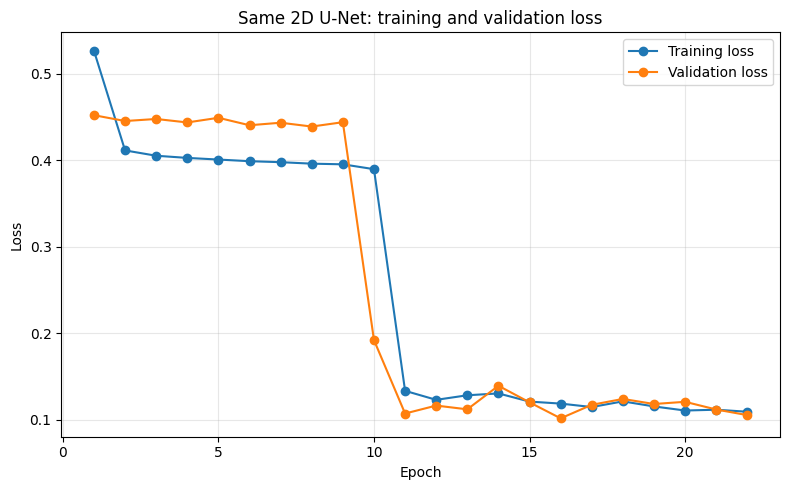

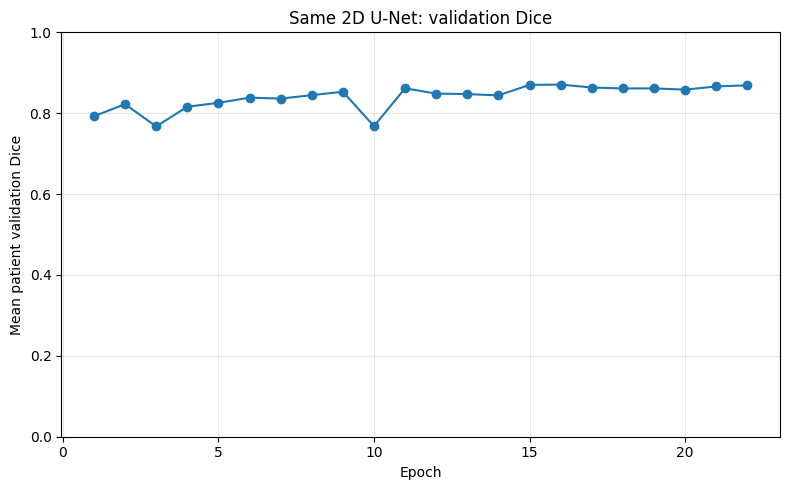

In [12]:
# Cell 12 — Save training graphs

plt.figure(figsize=(8, 5))
plt.plot(
    training_history["epoch"],
    training_history["training_loss"],
    marker="o",
    label="Training loss",
)
plt.plot(
    training_history["epoch"],
    training_history["validation_loss"],
    marker="o",
    label="Validation loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Same 2D U-Net: training and validation loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "training_loss.png",
    dpi=180,
)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    training_history["epoch"],
    training_history[
        "validation_patient_dice"
    ],
    marker="o",
)
plt.xlabel("Epoch")
plt.ylabel("Mean patient validation Dice")
plt.ylim(0, 1)
plt.title("Same 2D U-Net: validation Dice")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "validation_dice.png",
    dpi=180,
)
plt.show()

In [13]:
# Cell 13 — Create the final results ZIP

archive_path = shutil.make_archive(
    "/kaggle/working/brats_flair_same_model_improved_results",
    "zip",
    OUTPUT_ROOT,
)

print("Results folder:", OUTPUT_ROOT)
print("Downloadable ZIP:", archive_path)

Results folder: /kaggle/working/brats_flair_same_model_improved_outputs
Downloadable ZIP: /kaggle/working/brats_flair_same_model_improved_results.zip


In [14]:
# downloadable link:

In [15]:
from pathlib import Path

zip_path = Path(
    "/kaggle/working/brats_flair_same_model_improved_results.zip"
)

print("Exists:", zip_path.exists())

if zip_path.exists():
    print(
        "Size:",
        round(zip_path.stat().st_size / (1024 * 1024), 2),
        "MB",
    )

Exists: True
Size: 27.65 MB


In [16]:
import os
from IPython.display import FileLink, display

os.chdir("/kaggle/working")

display(
    FileLink(
        "brats_flair_same_model_improved_results.zip"
    )
)

/kaggle/working/brats_flair_same_model_improved_results.zip